# E-Commerce Sales Performance Analysis (Olist Dataset)

## Business Problem
Analyze sales performance, customer behavior, product trends, seller performance, payment methods, reviews, and regional sales using the Brazilian E-Commerce Public Dataset.

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)


## Step 1: Load Datasets

In [4]:

customers = pd.read_csv('olist_customers_dataset.csv')
orders = pd.read_csv('olist_orders_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
payments = pd.read_csv('olist_order_payments_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')
sellers = pd.read_csv('olist_sellers_dataset.csv')
category_translation = pd.read_csv('product_category_name_translation.csv')

for name, df in {
    'customers': customers,
    'orders': orders,
    'order_items': order_items,
    'products': products,
    'payments': payments,
    'reviews': reviews,
    'sellers': sellers
}.items():
    print(name, df.shape)


customers (99441, 5)
orders (99441, 8)
order_items (112650, 7)
products (32951, 9)
payments (103886, 5)
reviews (99224, 7)
sellers (3095, 4)


## Step 2: Data Cleaning

In [5]:

datasets = [customers, orders, order_items, products, payments, reviews, sellers]

for df in datasets:
    print(df.isnull().sum().sort_values(ascending=False).head())
    print("Duplicates:", df.duplicated().sum())
    print("-"*50)


customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64
Duplicates: 0
--------------------------------------------------
order_delivered_customer_date    2965
order_delivered_carrier_date     1783
order_approved_at                 160
order_id                            0
order_purchase_timestamp            0
dtype: int64
Duplicates: 0
--------------------------------------------------
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
dtype: int64
Duplicates: 0
--------------------------------------------------
product_category_name         610
product_description_lenght    610
product_name_lenght           610
product_photos_qty            610
product_weight_g                2
dtype: int64
Duplicates: 0
--------------------------------------------------
order_id                0
payment_sequential      0
p

## Step 3: Merge Datasets

In [6]:

products = products.merge(category_translation,
                          on='product_category_name',
                          how='left')

merged = (
    order_items
    .merge(orders, on='order_id', how='left')
    .merge(customers, on='customer_id', how='left')
    .merge(products, on='product_id', how='left')
    .merge(payments, on='order_id', how='left')
    .merge(reviews[['order_id','review_score']], on='order_id', how='left')
    .merge(sellers, on='seller_id', how='left')
)

merged.head()


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,payment_sequential,payment_type,payment_installments,payment_value,review_score,seller_zip_code_prefix,seller_city,seller_state
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29 00:00:00,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,cool_stuff,1.0,credit_card,2.0,72.19,5.0,27277,volta redonda,SP
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15 00:00:00,eb28e67c4c0b83846050ddfb8a35d051,15775,santa fe do sul,SP,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,pet_shop,1.0,credit_card,3.0,259.83,4.0,3471,sao paulo,SP
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05 00:00:00,3818d81c6709e39d06b2738a8d3a2474,35661,para de minas,MG,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,furniture_decor,1.0,credit_card,5.0,216.87,5.0,37564,borda da mata,MG
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20 00:00:00,af861d436cfc08b2c2ddefd0ba074622,12952,atibaia,SP,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0,perfumery,1.0,credit_card,2.0,25.78,4.0,14403,franca,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17 00:00:00,64b576fb70d441e8f1b2d7d446e483c5,13226,varzea paulista,SP,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,garden_tools,1.0,credit_card,3.0,218.04,5.0,87900,loanda,PR


## Business Question 1: Highest Revenue Categories

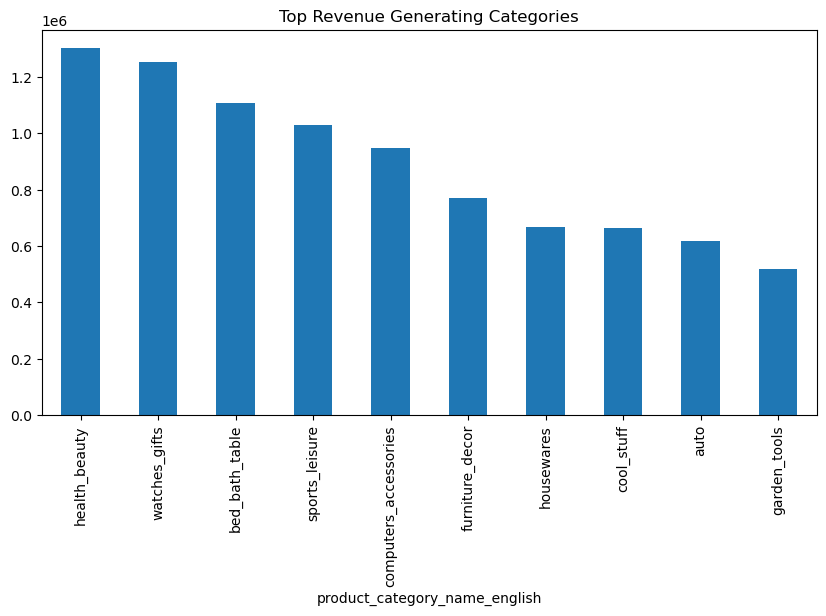

product_category_name_english
health_beauty            1301947.97
watches_gifts            1254322.95
bed_bath_table           1107249.09
sports_leisure           1029603.88
computers_accessories     950053.69
furniture_decor           772096.17
housewares                668880.94
cool_stuff                664637.13
auto                      618395.50
garden_tools              519473.33
Name: price, dtype: float64

In [7]:

category_revenue = merged.groupby(
    'product_category_name_english'
)['price'].sum().sort_values(ascending=False).head(10)

category_revenue.plot(kind='bar', figsize=(10,5))
plt.title('Top Revenue Generating Categories')
plt.show()

category_revenue


## Business Question 2: Highest Sales Cities

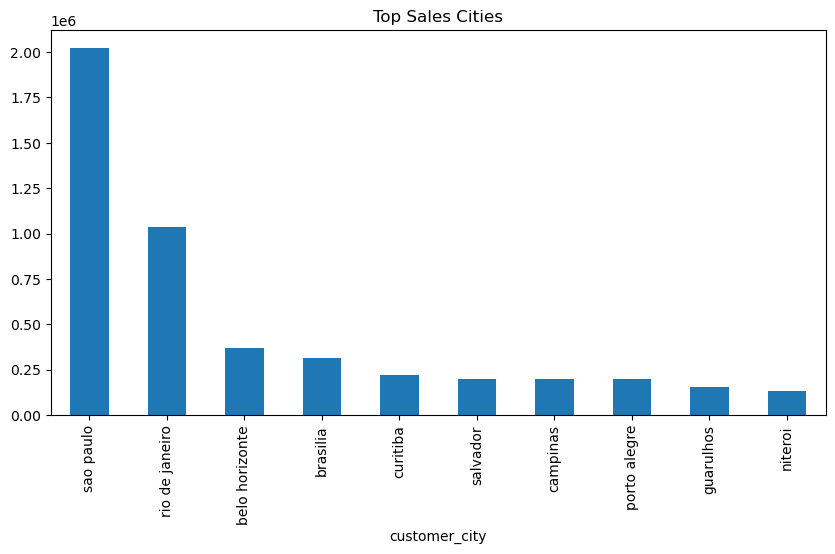

In [8]:

city_sales = merged.groupby('customer_city')['price'].sum()                    .sort_values(ascending=False).head(10)

city_sales.plot(kind='bar', figsize=(10,5))
plt.title('Top Sales Cities')
plt.show()


## Business Question 3: Customer Value Analysis

In [9]:

customer_value = merged.groupby('customer_unique_id')['payment_value'].sum()

customer_value.describe()


count     95420.000000
mean        213.968167
std         645.757464
min           0.000000
25%          63.990000
50%         113.330000
75%         203.300000
max      109312.640000
Name: payment_value, dtype: float64

## Business Question 4: Purchasing Patterns

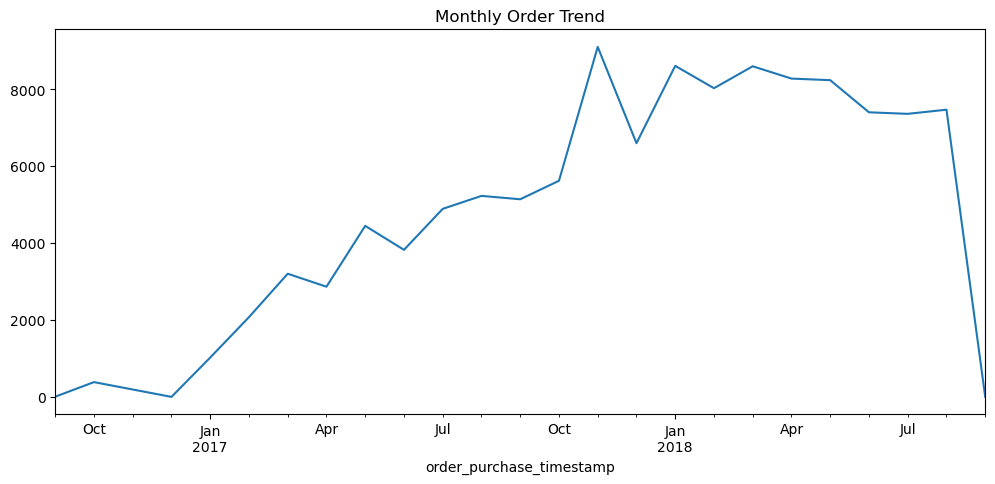

In [10]:

merged['order_purchase_timestamp'] = pd.to_datetime(
    merged['order_purchase_timestamp']
)

monthly_orders = merged.groupby(
    merged['order_purchase_timestamp'].dt.to_period('M')
).size()

monthly_orders.plot(figsize=(12,5))
plt.title('Monthly Order Trend')
plt.show()


## Business Question 5: Top Products

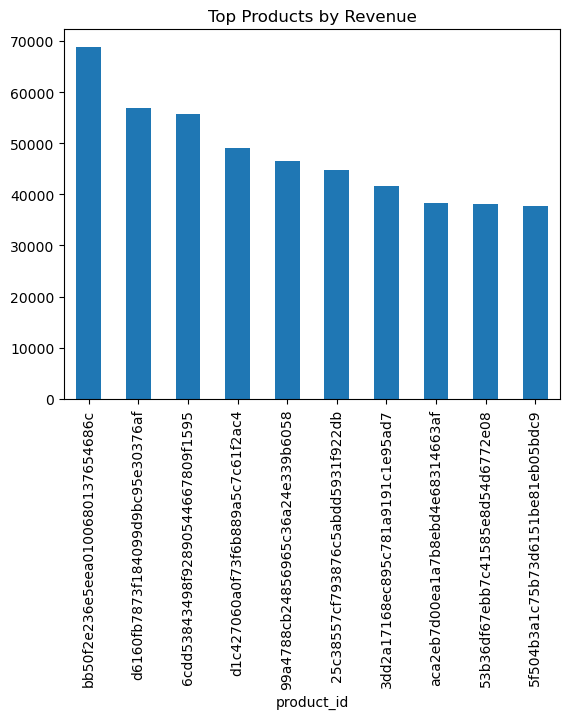

In [11]:

top_products = merged.groupby('product_id')['price'].sum()                      .sort_values(ascending=False).head(10)

top_products.plot(kind='bar')
plt.title('Top Products by Revenue')
plt.show()


## Business Question 6: Payment Method Analysis

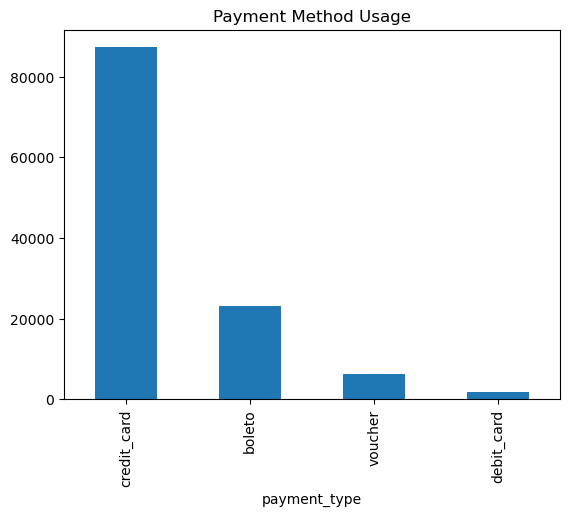

In [12]:

payment_summary = merged['payment_type'].value_counts()

payment_summary.plot(kind='bar')
plt.title('Payment Method Usage')
plt.show()


## Business Question 7: Top Sellers

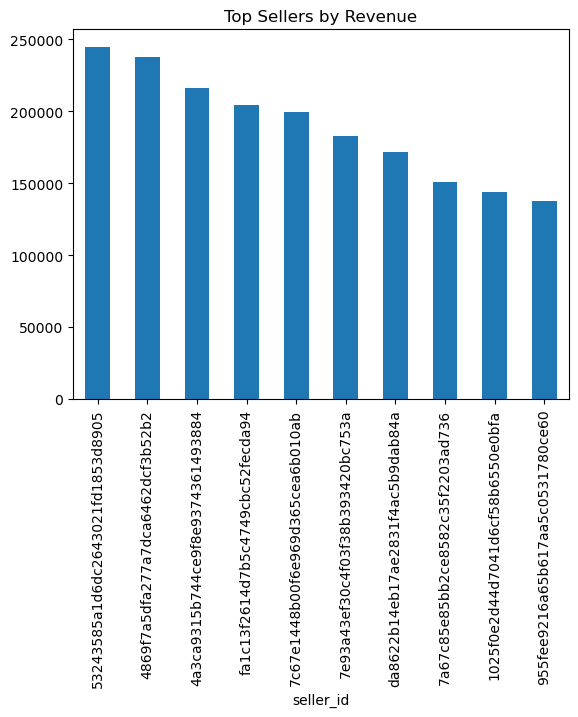

In [13]:

top_sellers = merged.groupby('seller_id')['price'].sum()                     .sort_values(ascending=False).head(10)

top_sellers.plot(kind='bar')
plt.title('Top Sellers by Revenue')
plt.show()


## Business Question 8: Review Scores by Category

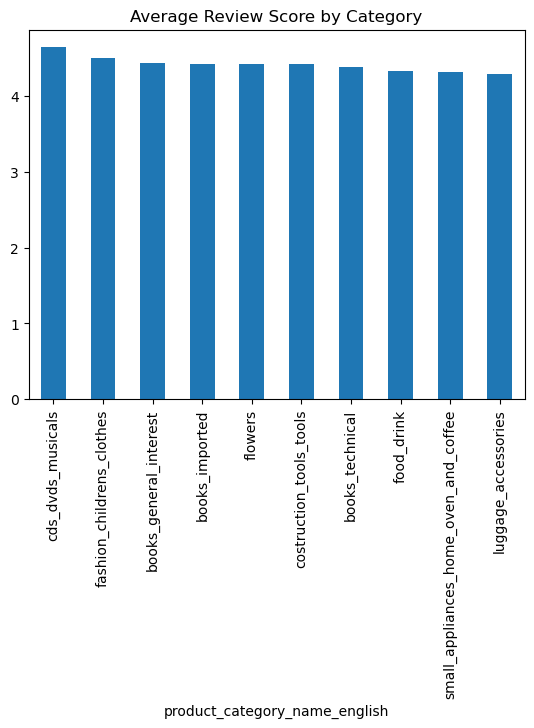

In [14]:

review_category = merged.groupby(
    'product_category_name_english'
)['review_score'].mean().sort_values(ascending=False).head(10)

review_category.plot(kind='bar')
plt.title('Average Review Score by Category')
plt.show()


## Business Question 9: Sales Over Time

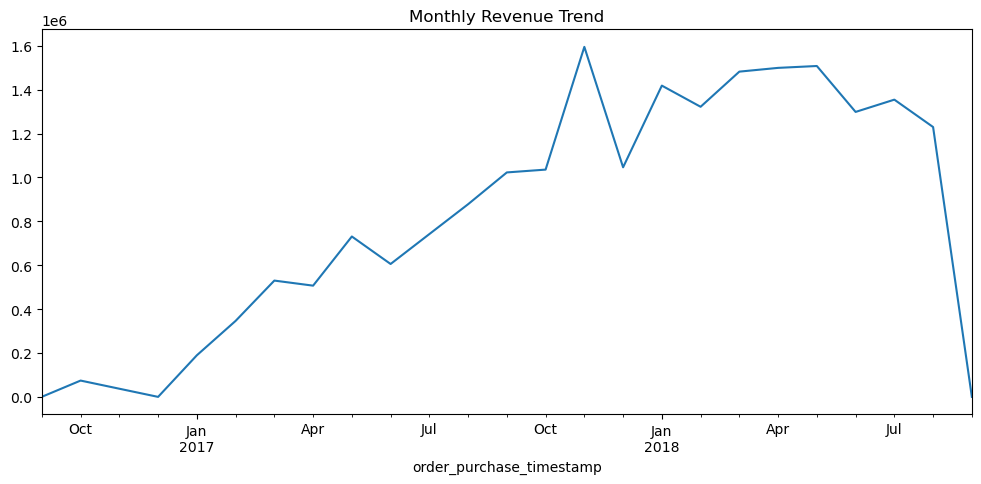

In [15]:

monthly_revenue = merged.groupby(
    merged['order_purchase_timestamp'].dt.to_period('M')
)['payment_value'].sum()

monthly_revenue.plot(figsize=(12,5))
plt.title('Monthly Revenue Trend')
plt.show()


## Business Question 10: Repeat Customers

In [16]:

repeat_customers = merged.groupby(
    'customer_unique_id'
)['order_id'].nunique()

print("Repeat Customers:", (repeat_customers > 1).sum())
print("One-time Customers:", (repeat_customers == 1).sum())


Repeat Customers: 2913
One-time Customers: 92507


## Data Quality Report

In [17]:

print("Missing Values")
print(merged.isnull().sum().sort_values(ascending=False).head(20))

print("\nDuplicate Rows:", merged.duplicated().sum())


Missing Values
order_delivered_customer_date    2588
product_category_name_english    1734
product_name_lenght              1709
product_description_lenght       1709
product_photos_qty               1709
product_category_name            1709
order_delivered_carrier_date     1254
review_score                      978
product_length_cm                  20
product_weight_g                   20
product_height_cm                  20
product_width_cm                   20
order_approved_at                  15
payment_sequential                  3
payment_type                        3
payment_value                       3
payment_installments                3
order_id                            0
order_item_id                       0
product_id                          0
dtype: int64

Duplicate Rows: 419


## Final Conclusions & Recommendations

- Identify top revenue categories.
- Focus marketing on high-performing cities.
- Reward high-value customers.
- Improve low-rated categories.
- Strengthen relationships with top sellers.
- Optimize payment methods preferred by customers.

#hrlloabs
##hgugabs
###jhbhbb 

# hgfhgfuf 